# 2막. 탐색 - 클러스터링 기반 패턴 분석

[1막(`01_eda.ipynb`)](./01_eda.ipynb)에서 두 가지를 확인했다.

- 사기 거래는 전체의 0.58%에 불과한 극단적 불균형 데이터다.
- 사기 거래의 금액(`amt`)은 정상 거래보다 통계적으로 유의하게, 그리고 실질적으로도 크다(평균 기준 약 8배).
- 시간대·카테고리별로도 사기 비율이 균일하지 않았다.

이 노트북은 그 관찰을 한 단계 더 밀고 나가, **"사기가 특정 조건들의 조합에 몰려있는가?"**를 클러스터링으로 확인한다. 목표는 정교한 분류 모델을 만드는 것이 아니라, 사기가 밀집된 거래군의 특징을 프로파일링하고 이를 3막(`03_modeling.ipynb`)에서 검증할 feature 후보로 정리하는 것이다.

## Section 0. 환경설정

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

# 시스템에 설치된 한글 폰트를 우선순위대로 탐색해 적용 (없으면 기본 폰트 유지)
# 주의: sns.set_style()이 rcParams의 font.family를 초기화하므로 반드시 그 다음에 설정해야 한다.
korean_font_candidates = [
    "AppleGothic",
    "Apple SD Gothic Neo",
    "Noto Sans CJK KR",
    "NanumGothic",
    "Malgun Gothic",
]
available_fonts = {f.name for f in fm.fontManager.ttflist}
for font_name in korean_font_candidates:
    if font_name in available_fonts:
        plt.rcParams["font.family"] = font_name
        break
else:
    warnings.warn("한글 폰트를 찾지 못했습니다. 그래프의 한글이 깨질 수 있습니다.")

plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_columns", None)
print(f"적용된 폰트: {plt.rcParams['font.family']}")

적용된 폰트: ['AppleGothic']


In [2]:
df = pd.read_csv("../data/credit.csv")
df["trans_hour"] = pd.to_datetime(df["trans_date_trans_time"]).dt.hour

print(f"shape: {df.shape}")
df[["trans_date_trans_time", "trans_hour", "category", "amt", "is_fraud"]].head()

shape: (1296675, 25)


,trans_date_trans_time,trans_hour,category,amt,is_fraud
0,2019-01-01 00:00:18,0,misc_net,4.97,0
1,2019-01-01 00:00:44,0,grocery_pos,107.23,0
2,2019-01-01 00:00:51,0,entertainment,220.11,0
3,2019-01-01 00:01:16,0,gas_transport,45.00,0
4,2019-01-01 00:03:06,0,misc_pos,41.96,0


## Section 1. 클러스터링용 feature 준비

클러스터링에 사용할 feature와 선택 이유:

- **`amt_log`** — 1막에서 확인했듯 `amt`는 오른쪽으로 긴 꼬리를 가진 분포이고, 사기 여부에 따라 스케일 차이가 크다. 로그 변환(`log1p`)으로 왜도를 줄여야 큰 금액 몇 건이 거리 기반 클러스터링을 왜곡하지 않는다.
- **`trans_hour`** — 1막에서 시간대별 사기 비율이 균일하지 않음을 확인했다. 심야/새벽 등 특정 시간대에 사기가 몰리는지 클러스터 단위에서 재확인한다.
- **`distance_km`** — 카드 소지자 위치(`lat`, `long`)와 가맹점 위치(`merch_lat`, `merch_long`) 사이의 haversine 거리. 카드 소지자의 평소 활동 반경에서 멀리 떨어진 거래는 도난/복제 카드 사용의 전형적 신호이며, 원본 데이터에는 없는 새로운 파생 feature다.
- **`category` (원-핫 인코딩)** — 1막에서 카테고리별 사기 비율 편차를 확인했지만, 그 사기 비율 자체(target encoding)를 feature로 쓰면 `is_fraud`를 직접 클러스터에 주입하는 셈이 되어 이후 3막에서 이 클러스터 라벨을 예측 feature로 쓸 때 **데이터 누수(leakage)**가 발생한다. 따라서 카테고리는 사기 비율이 아니라 원-핫 인코딩으로 "안전하게" 반영한다.

이후 모든 feature는 `StandardScaler`로 정규화한다. K-means는 유클리드 거리 기반이므로 스케일이 큰 변수(예: `amt_log`)가 거리 계산을 지배하지 않도록 하기 위함이다.

In [3]:
def haversine_distance(lat1, lon1, lat2, lon2):
    """카드 소지자-가맹점 간 거리(km)를 haversine 공식으로 계산."""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


df["amt_log"] = np.log1p(df["amt"])
df["distance_km"] = haversine_distance(df["lat"], df["long"], df["merch_lat"], df["merch_long"])

df[["amt", "amt_log", "trans_hour", "distance_km"]].describe().round(2)

,amt,amt_log,trans_hour,distance_km
count,1296675.00,1296675.00,1296675.00,1296675.00
mean,70.35,3.53,12.80,76.11
std,160.32,1.29,6.82,29.12
min,1.00,0.69,0.00,0.02
25%,9.65,2.37,7.00,55.33
50%,47.52,3.88,14.00,78.23
75%,83.14,4.43,19.00,98.50
max,28948.90,10.27,23.00,152.12


In [4]:
numeric_features = ["amt_log", "trans_hour", "distance_km"]
category_dummies = pd.get_dummies(df["category"], prefix="cat")

feature_df = pd.concat([df[numeric_features], category_dummies], axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(feature_df)

print(f"feature matrix shape: {X_scaled.shape}")
feature_df.columns.tolist()

feature matrix shape: (1296675, 17)


['amt_log',
 'trans_hour',
 'distance_km',
 'cat_entertainment',
 'cat_food_dining',
 'cat_gas_transport',
 'cat_grocery_net',
 'cat_grocery_pos',
 'cat_health_fitness',
 'cat_home',
 'cat_kids_pets',
 'cat_misc_net',
 'cat_misc_pos',
 'cat_personal_care',
 'cat_shopping_net',
 'cat_shopping_pos',
 'cat_travel']

## Section 2. 적정 클러스터 개수 탐색

k=2~8 범위에서 inertia(elbow method)와 실루엣 스코어를 함께 확인해 적정 k를 정한다. 데이터가 130만 건이라 실루엣 스코어는 전체를 다 계산하면 비용이 너무 크므로(쌍별 거리 계산이 O(n²)), 10,000건 무작위 샘플로 근사한다.

In [5]:
k_range = range(2, 9)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels, sample_size=10_000, random_state=42)
    silhouettes.append(sil)
    print(f"k={k}: inertia={km.inertia_:,.0f}, silhouette={sil:.4f}")

k=2: inertia=20,016,366, silhouette=0.1259


k=3: inertia=18,562,829, silhouette=0.1409


k=4: inertia=17,045,904, silhouette=0.1977


k=5: inertia=15,608,157, silhouette=0.2287


k=6: inertia=14,206,899, silhouette=0.2811


k=7: inertia=12,791,203, silhouette=0.3384


k=8: inertia=11,371,333, silhouette=0.3806


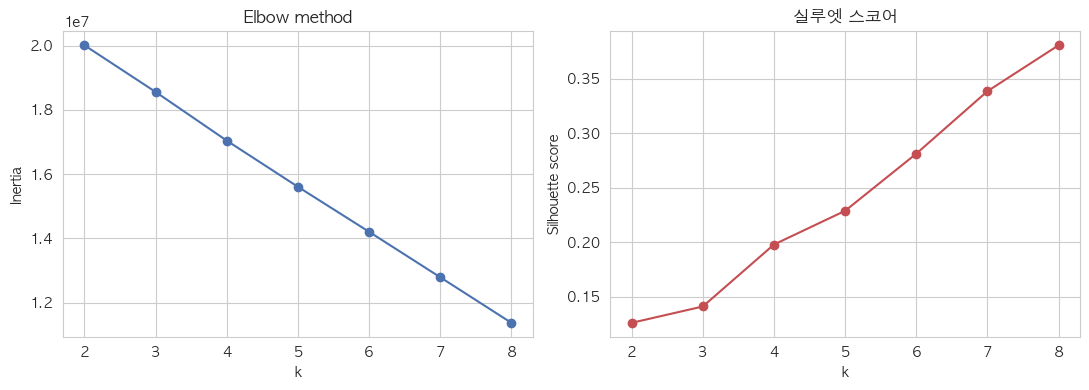

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(list(k_range), inertias, marker="o", color="#4C72B0")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow method")

axes[1].plot(list(k_range), silhouettes, marker="o", color="#C44E52")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("실루엣 스코어")

plt.tight_layout()
plt.show()

**k 선택 근거**

| k | inertia | silhouette |
|---|---|---|
| 2 | 20,016,366 | 0.1259 |
| 3 | 18,562,829 | 0.1409 |
| 4 | 17,045,904 | 0.1977 |
| 5 | 15,608,157 | 0.2287 |
| 6 | 14,206,899 | 0.2811 |
| 7 | 12,791,203 | 0.3384 |
| 8 | 11,371,333 | 0.3806 |

inertia는 k=2~8 구간에서 뚜렷한 꺾임(elbow) 없이 거의 선형으로 감소하고, 실루엣 스코어도 k=8까지 꾸준히 증가한다. 두 지표만 보면 k를 최대한 키우고 싶어지지만, 이 데이터의 feature 17개 중 14개가 `category` 원-핫 더미라는 점을 감안해야 한다 — k를 키울수록 클러스터가 단순히 카테고리 조합을 더 잘게 쪼개는 방향으로 실루엣이 오르는 것이지, 반드시 더 의미 있는 사기 패턴을 찾아내는 것은 아니다.

따라서 지표를 맹목적으로 최대화하기보다 **해석 가능성**을 기준으로 `k=4`를 선택한다. k=2→3 대비 k=3→4 구간에서 실루엣이 가장 크게 뛰고(+0.057), 4개 클러스터는 Section 3에서 사람이 읽을 수 있는 수준으로 프로파일링하기에 적당한 개수다.

## Section 3. K-means 클러스터링 및 클러스터별 사기 비율

In [7]:
chosen_k = 4  # Section 2의 elbow/실루엣 결과에 따라 결정 (근거는 위 markdown 참고)

kmeans_final = KMeans(n_clusters=chosen_k, n_init=10, random_state=42)
df["cluster"] = kmeans_final.fit_predict(X_scaled)

cluster_fraud_rate = (df.groupby("cluster")["is_fraud"].mean() * 100).round(3)
cluster_size = df.groupby("cluster").size()

cluster_summary = pd.DataFrame({"count": cluster_size, "fraud_rate(%)": cluster_fraud_rate})
cluster_summary

,count,fraud_rate(%)
cluster,,
0,300980,0.841
1,397381,0.958
2,85879,0.155
3,512435,0.202


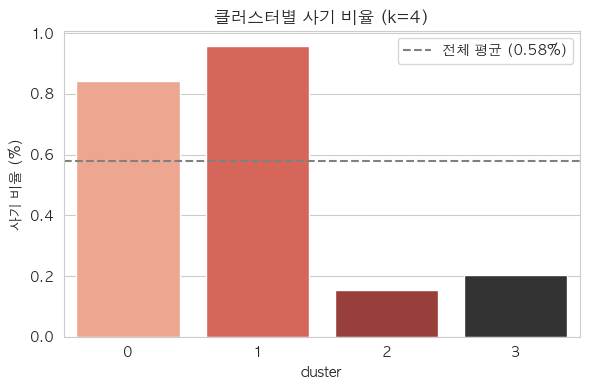

In [8]:
overall_rate = df["is_fraud"].mean() * 100

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=cluster_summary.index, y=cluster_summary["fraud_rate(%)"], hue=cluster_summary.index,
            palette="Reds_d", legend=False, ax=ax)
ax.axhline(overall_rate, color="gray", linestyle="--", label=f"전체 평균 ({overall_rate:.2f}%)")
ax.set_xlabel("cluster")
ax.set_ylabel("사기 비율 (%)")
ax.set_title(f"클러스터별 사기 비율 (k={chosen_k})")
ax.legend()

plt.tight_layout()
plt.show()

In [9]:
profile = df.groupby("cluster")[["amt", "distance_km", "trans_hour"]].mean().round(2)
profile["fraud_rate(%)"] = cluster_fraud_rate
profile["count"] = cluster_size

top_category = df.groupby("cluster")["category"].agg(lambda s: s.value_counts().idxmax())
profile["top_category"] = top_category

profile

,amt,distance_km,trans_hour,fraud_rate(%),count,top_category
cluster,,,,,,
0,86.10,76.17,5.58,0.841,300980,gas_transport
1,79.07,76.18,11.99,0.958,397381,shopping_pos
2,54.18,75.89,17.50,0.155,85879,health_fitness
3,57.05,76.07,16.89,0.202,512435,home


**클러스터 해석**

| cluster | count | fraud_rate(%) | amt(평균) | distance_km(평균) | trans_hour(평균) | top_category |
|---|---|---|---|---|---|---|
| 0 | 300,980 | 0.841 | 86.10 | 76.17 | 5.58 (새벽) | gas_transport |
| 1 | 397,381 | 0.958 | 79.07 | 76.18 | 11.99 (정오) | shopping_pos |
| 2 | 85,879 | 0.155 | 54.18 | 75.89 | 17.50 (저녁) | health_fitness |
| 3 | 512,435 | 0.202 | 57.05 | 76.07 | 16.89 (오후) | home |

전체 평균 사기 비율(0.58%)을 기준으로 보면 뚜렷하게 갈린다.

- **cluster 1 (정오, 오프라인 쇼핑 중심)**: 사기 비율 0.958%로 전체 평균의 약 1.65배. 가장 위험한 거래군이다.
- **cluster 0 (새벽, 주유/교통 중심)**: 사기 비율 0.841%로 평균보다 높다. 새벽 시간대 거래라는 점이 시간대 기반 사기 신호(1막에서 확인)와 일치한다.
- **cluster 2 (저녁, 건강/피트니스)**, **cluster 3 (오후, 가정용품)**: 사기 비율이 각각 0.155%, 0.202%로 평균을 크게 밑돈다. 이 두 클러스터가 전체 거래의 약 46%(598,314건)를 차지하는 "저위험 거래군"이다.

다만 `distance_km`는 클러스터마다 75.9~76.2km로 거의 차이가 없다. 즉 이번 클러스터링에서 카드 소지자-가맹점 거리는 클러스터를 가르는 데 별로 기여하지 못했고, 실질적으로는 **시간대와 카테고리**가 클러스터 구분을 주도했다. 이는 feature 17개 중 14개가 카테고리 원-핫 더미였던 구성상 자연스러운 결과이며, 거리가 정말 사기와 무관한지는 3막에서 단일 feature로서 다시 검증할 필요가 있다.

**한계점: category 원-핫 인코딩의 구조적 지배**

이 클러스터링에는 눈에 띄는 방법론적 한계가 있다. 전체 17차원 중 `category` 원-핫 더미가 14차원을 차지해, 수치형 feature(`amt_log`, `trans_hour`, `distance_km`)는 단 3차원뿐이다. K-means는 유클리드 거리 기반이므로, 차원이 많을수록 전체 거리 계산에서 차지하는 영향력도 커진다 — 즉 `category`가 의도적으로 가중치를 준 것이 아님에도 **차원 수 자체 때문에** 구조적으로 클러스터링을 지배했을 가능성이 높다. 실제로 위에서 확인한 대로 `distance_km`가 클러스터 간 거의 차이를 만들지 못한 것도 이 때문일 수 있다.

**개선 방향**: 원-핫 인코딩 이후 PCA로 차원을 축소해 category 정보를 압축한 뒤 재클러스터링하거나, category 더미에 낮은 가중치(예: `sqrt(1/14)` 스케일링)를 곱해 수치형 feature와 균형을 맞추는 방식으로 이 편향을 완화하고 결과가 달라지는지 검증해볼 수 있다.

## Section 4. 다음 단계 예고

클러스터 라벨 자체와, 각 거래가 자신이 속한 클러스터 중심으로부터 얼마나 떨어져 있는지(`cluster_dist`, 이상치일수록 커짐)를 새로운 feature 후보로 저장한다.

**주의**: 여기서는 사기가 특정 클러스터에 몰려있다는 "탐색"까지만 한다. 이 클러스터 라벨/거리가 실제로 예측 성능(precision, recall, PR-AUC)에 기여하는지는 3막(`03_modeling.ipynb`)에서 다른 feature들과 함께 검증한다. 클러스터링 자체는 비지도 학습이므로, 그 결과가 유용한 신호인지는 지도학습 단계에서 별도로 확인해야 한다.

In [10]:
df["cluster_dist"] = np.linalg.norm(X_scaled - kmeans_final.cluster_centers_[df["cluster"]], axis=1)

cluster_features = df[["trans_num", "cluster", "cluster_dist", "is_fraud"]]
cluster_features.to_csv("../data/cluster_features.csv", index=False)

print(f"저장 완료: data/cluster_features.csv ({len(cluster_features):,} rows)")
cluster_features.head()

저장 완료: data/cluster_features.csv (1,296,675 rows)


,trans_num,cluster,cluster_dist,is_fraud
0,0b242abb623afc578575680df30655b9,1,4.688363,0
1,1f76529f8574734946361c461b024d99,0,3.167755,0
2,a1a22d70485983eac12b5b88dad1cf95,3,4.637077,0
3,6b849c168bdad6f867558c3793159a81,0,2.713660,0
4,a41d7549acf90789359a9aa5346dcb46,1,4.180717,0


## 결론

1. k=4로 클러스터링한 결과 사기 비율이 클러스터별로 0.155%~0.958%까지 최대 6배 차이가 났고, 특히 정오·오프라인 쇼핑 중심 클러스터(cluster 1)와 새벽·주유 중심 클러스터(cluster 0)에 사기가 몰려있었다.
2. 다만 카드 소지자-가맹점 거리(`distance_km`)는 클러스터 간 차이가 거의 없어, 이번 구성에서는 거리보다 시간대·카테고리가 클러스터를 더 강하게 좌우했다 — 거리 feature의 실제 유효성은 추가 검증이 필요하다.
3. 클러스터 라벨과 클러스터 중심까지의 거리(`cluster_dist`)를 `data/cluster_features.csv`에 저장했으며, 이 feature들이 실제로 예측 성능에 기여하는지는 3막(`03_modeling.ipynb`)에서 검증한다.